# **Data 201 - Project 2**
## **Introduction**

The data selected is available at https://capitalbikeshare.com/system-data. The data in question is the trips made in washington dc bike share system. It has originally 14 rows, they are:
ride_id, "rideable_type", "started_at", "ended_at",

*   ride_id: Identification number, not much importance.
*   "rideable_type": clasifies the bike usede between eletric and classic.
*   "started_at": Time the trip started, hour:minute:second day/month/year
*  "ended_at" : Time the trip endedhour:minute:second day/month/year
*  "start_station_name": name of the station the trip started, troubling, lots of missing itens.
*  "start_station_id": id of the station the trip started, troubling, lots of missing itens
*  "end_station_name": name of the station the trip ended, troubling, lots of missing itens
*  "end_station_id": id of the station the trip ended, troubling, lots of missing itens
*  "start_lat": latitude of the station the trip started, troubling, lots of missing itens
*  "start_lng": longitude of the station the trip started, troubling, lots of missing itens
*  "end_lat": latitude of the station the trip ended, troubling, lots of missing itens
*  "end_lng": longitude of the station the trip ended, troubling, lots of missing itens
*  "member_casual": classifies the rider between member or casual.

The project wants to anallyse the number of trips per hour, distiguishing them per type of bike and type of member.2

In [ ]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta


df_01 = pd.read_csv('202503-capitalbikeshare-tripdata.csv')

df_01.info()

df_01.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626757 entries, 0 to 626756
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             626757 non-null  object 
 1   rideable_type       626757 non-null  object 
 2   started_at          626757 non-null  object 
 3   ended_at            626757 non-null  object 
 4   start_station_name  460635 non-null  object 
 5   start_station_id    460635 non-null  float64
 6   end_station_name    456924 non-null  object 
 7   end_station_id      456837 non-null  float64
 8   start_lat           626757 non-null  float64
 9   start_lng           626757 non-null  float64
 10  end_lat             626434 non-null  float64
 11  end_lng             626434 non-null  float64
 12  member_casual       626757 non-null  object 
dtypes: float64(6), object(7)
memory usage: 62.2+ MB


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B62C76AD61DFE4A5,classic_bike,2025-03-07 08:45:59.496,2025-03-07 08:47:56.041,20th & O St NW / Dupont South,31234.0,New Hampshire Ave & Ward Pl NW,31212.0,38.908905,-77.044780,38.905711,-77.047318,member
1,20883512A96C1496,electric_bike,2025-03-24 09:37:36.233,2025-03-24 09:45:26.549,33rd St & Wisconsin Ave NW,31337.0,18th & L St NW,31224.0,38.912181,-77.066074,38.903741,-77.042452,member
2,34DB085578274D9C,classic_bike,2025-03-10 08:37:28.678,2025-03-10 09:19:04.343,Langston Blvd & N Cleveland St,31079.0,1st & I St SE,31628.0,38.894941,-77.091690,38.878854,-77.005727,member
3,1804A3706C620EC8,classic_bike,2025-03-11 08:39:00.732,2025-03-11 09:24:04.729,Langston Blvd & N Cleveland St,31079.0,1st & I St SE,31628.0,38.894941,-77.091690,38.878854,-77.005727,member
4,5A6A07F6A594DBC5,classic_bike,2025-03-25 08:22:12.145,2025-03-25 09:07:29.835,Langston Blvd & N Cleveland St,31079.0,1st & I St SE,31628.0,38.894941,-77.091690,38.878854,-77.005727,member


In [ ]:
df_01.shape[0]

626434

In [ ]:
print(df_01.isna().sum())

ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    166122
start_station_id      166122
end_station_name      169833
end_station_id        169920
start_lat                  0
start_lng                  0
end_lat                  323
end_lng                  323
member_casual              0
dtype: int64


In [ ]:
# prompt: delete rows where end_lat are NAs

# Drop rows where 'end_lat' is NA
df_01 = df_01.dropna(subset=['end_lat'])

df_01.head()

print(df_01.isna().sum())


ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    166122
start_station_id      166122
end_station_name      169510
end_station_id        169597
start_lat                  0
start_lng                  0
end_lat                    0
end_lng                    0
member_casual              0
dtype: int64


In [ ]:
df_01['started_at'] = pd.to_datetime(df_01['started_at'])
df_01['ended_at'] = pd.to_datetime(df_01['ended_at'])
df_01.info()

<class 'pandas.core.frame.DataFrame'>
Index: 626434 entries, 0 to 626756
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             626434 non-null  object        
 1   rideable_type       626434 non-null  object        
 2   started_at          626434 non-null  datetime64[ns]
 3   ended_at            626434 non-null  datetime64[ns]
 4   start_station_name  460312 non-null  object        
 5   start_station_id    460312 non-null  float64       
 6   end_station_name    456924 non-null  object        
 7   end_station_id      456837 non-null  float64       
 8   start_lat           626434 non-null  float64       
 9   start_lng           626434 non-null  float64       
 10  end_lat             626434 non-null  float64       
 11  end_lng             626434 non-null  float64       
 12  member_casual       626434 non-null  object        
dtypes: datetime64[ns](2), float64(6), 

# New project

In [ ]:
df_01['total_time'] = (df_01['ended_at'] - df_01['started_at']).dt.total_seconds()


df_01.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,total_time
0,B62C76AD61DFE4A5,classic_bike,2025-03-07 08:45:59.496,2025-03-07 08:47:56.041,20th & O St NW / Dupont South,31234.0,New Hampshire Ave & Ward Pl NW,31212.0,38.908905,-77.044780,38.905711,-77.047318,member,116.545
1,20883512A96C1496,electric_bike,2025-03-24 09:37:36.233,2025-03-24 09:45:26.549,33rd St & Wisconsin Ave NW,31337.0,18th & L St NW,31224.0,38.912181,-77.066074,38.903741,-77.042452,member,470.316
2,34DB085578274D9C,classic_bike,2025-03-10 08:37:28.678,2025-03-10 09:19:04.343,Langston Blvd & N Cleveland St,31079.0,1st & I St SE,31628.0,38.894941,-77.091690,38.878854,-77.005727,member,2495.665
3,1804A3706C620EC8,classic_bike,2025-03-11 08:39:00.732,2025-03-11 09:24:04.729,Langston Blvd & N Cleveland St,31079.0,1st & I St SE,31628.0,38.894941,-77.091690,38.878854,-77.005727,member,2703.997
4,5A6A07F6A594DBC5,classic_bike,2025-03-25 08:22:12.145,2025-03-25 09:07:29.835,Langston Blvd & N Cleveland St,31079.0,1st & I St SE,31628.0,38.894941,-77.091690,38.878854,-77.005727,member,2717.690


In [ ]:
# Create a new DataFrame with selected columns
new_df = df_01[['member_casual', 'total_time', 'started_at', 'rideable_type', 'end_lat', 'end_lng', 'start_lat', 'start_lng']].copy()

# Transform 'member_casual' column
new_df['member_casual'] = new_df['member_casual'].apply(lambda x: "1" if x == "member" else "0")

# Transform 'rideble_type' column
new_df['rideable_type'] = new_df['rideable_type'].apply(lambda x: "1" if x == "electric_bike" else "0")

# Display the first few rows of the new DataFrame
print(new_df.head())

# Save the new DataFrame to a CSV file
#new_df.to_csv('new_dataset.csv', index=False)


  member_casual  total_time              started_at rideable_type    end_lat  \
0             1     116.545 2025-03-07 08:45:59.496             0  38.905711   
1             1     470.316 2025-03-24 09:37:36.233             1  38.903741   
2             1    2495.665 2025-03-10 08:37:28.678             0  38.878854   
3             1    2703.997 2025-03-11 08:39:00.732             0  38.878854   
4             1    2717.690 2025-03-25 08:22:12.145             0  38.878854   

     end_lng  start_lat  start_lng  
0 -77.047318  38.908905 -77.044780  
1 -77.042452  38.912181 -77.066074  
2 -77.005727  38.894941 -77.091690  
3 -77.005727  38.894941 -77.091690  
4 -77.005727  38.894941 -77.091690  


In [ ]:
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

# Apply the haversine function to create the new column
new_df['distance'] = new_df.apply(lambda row: haversine(row['start_lng'], row['start_lat'], row['end_lng'], row['end_lat']), axis=1)

print(new_df.head())


  member_casual  total_time              started_at rideable_type    end_lat  \
0             1     116.545 2025-03-07 08:45:59.496             0  38.905711   
1             1     470.316 2025-03-24 09:37:36.233             1  38.903741   
2             1    2495.665 2025-03-10 08:37:28.678             0  38.878854   
3             1    2703.997 2025-03-11 08:39:00.732             0  38.878854   
4             1    2717.690 2025-03-25 08:22:12.145             0  38.878854   

     end_lng  start_lat  start_lng  distance  
0 -77.047318  38.908905 -77.044780  0.417571  
1 -77.042452  38.912181 -77.066074  2.249071  
2 -77.005727  38.894941 -77.091690  7.652300  
3 -77.005727  38.894941 -77.091690  7.652300  
4 -77.005727  38.894941 -77.091690  7.652300  


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


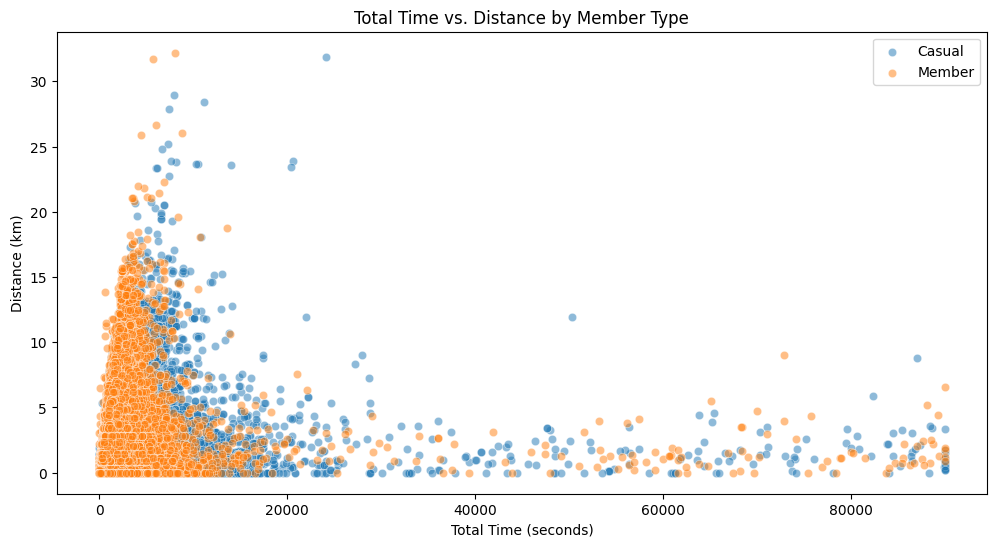

In [ ]:
plt.figure(figsize=(12, 6))

# Filter for casual members
casual_members = new_df[new_df['member_casual'] == '0']
sns.scatterplot(x='total_time', y='distance', data=casual_members, label='Casual', alpha=0.5)

# Filter for member members
member_members = new_df[new_df['member_casual'] == '1']
sns.scatterplot(x='total_time', y='distance', data=member_members, label='Member', alpha=0.5)


plt.xlabel('Total Time (seconds)')
plt.ylabel('Distance (km)')
plt.title('Total Time vs. Distance by Member Type')
plt.legend()
plt.show()


In [ ]:
new_df.head()

,member_casual,total_time,started_at,rideable_type,end_lat,end_lng,start_lat,start_lng,distance
0,1,116.545,2025-03-07 08:45:59.496,0,38.905711,-77.047318,38.908905,-77.044780,0.417571
1,1,470.316,2025-03-24 09:37:36.233,1,38.903741,-77.042452,38.912181,-77.066074,2.249071
2,1,2495.665,2025-03-10 08:37:28.678,0,38.878854,-77.005727,38.894941,-77.091690,7.652300
3,1,2703.997,2025-03-11 08:39:00.732,0,38.878854,-77.005727,38.894941,-77.091690,7.652300
4,1,2717.690,2025-03-25 08:22:12.145,0,38.878854,-77.005727,38.894941,-77.091690,7.652300


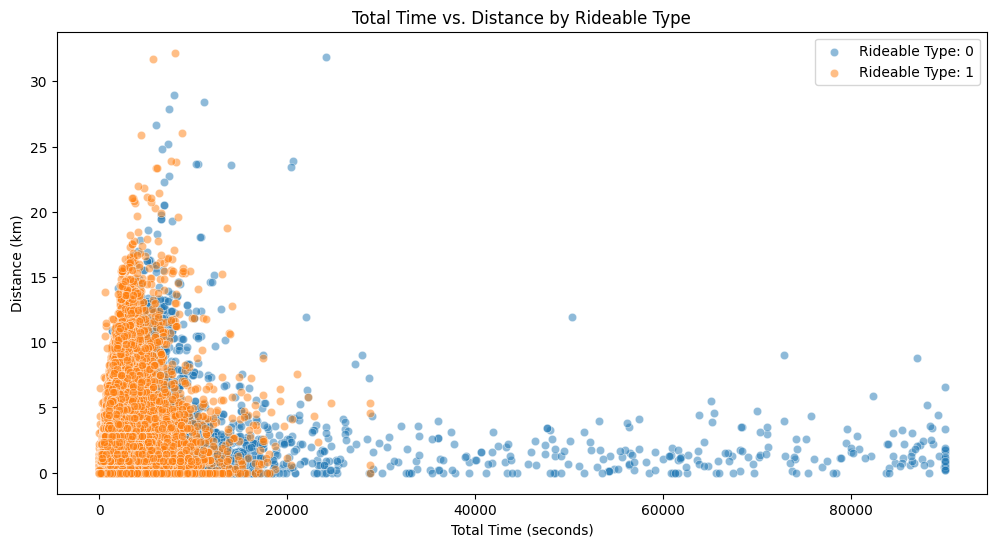

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Filter for different rideable types
for rideable_type in new_df['rideable_type'].unique():
    subset = new_df[new_df['rideable_type'] == rideable_type]
    sns.scatterplot(x='total_time', y='distance', data=subset, label=f'Rideable Type: {rideable_type}', alpha=0.5)

plt.xlabel('Total Time (seconds)')
plt.ylabel('Distance (km)')
plt.title('Total Time vs. Distance by Rideable Type')
plt.legend()
plt.show()


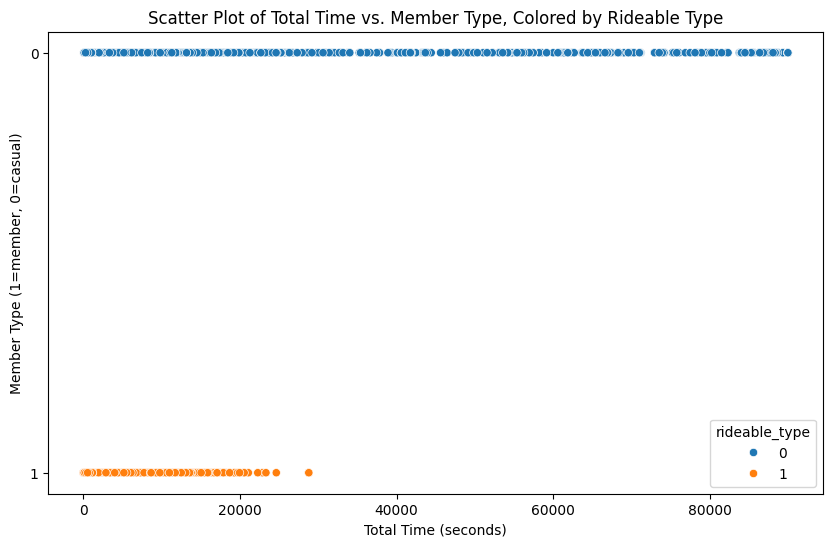

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_time', y='rideable_type', hue='rideable_type', data=new_df)
plt.title('Scatter Plot of Total Time vs. Member Type, Colored by Rideable Type')
plt.xlabel('Total Time (seconds)')
plt.ylabel('Member Type (1=member, 0=casual)')
plt.show()


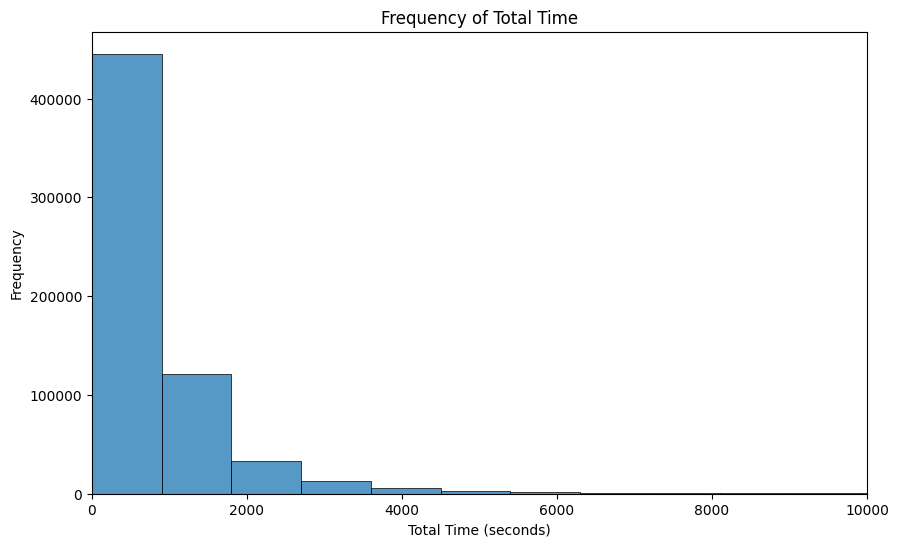

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(new_df['total_time'], bins=100)  # Adjust bins as needed for better visualization
plt.title('Frequency of Total Time')
plt.xlabel('Total Time (seconds)')
plt.ylabel('Frequency')
plt.xlim(0, 10000)  # Limit the x-axis to 10000
plt.show()


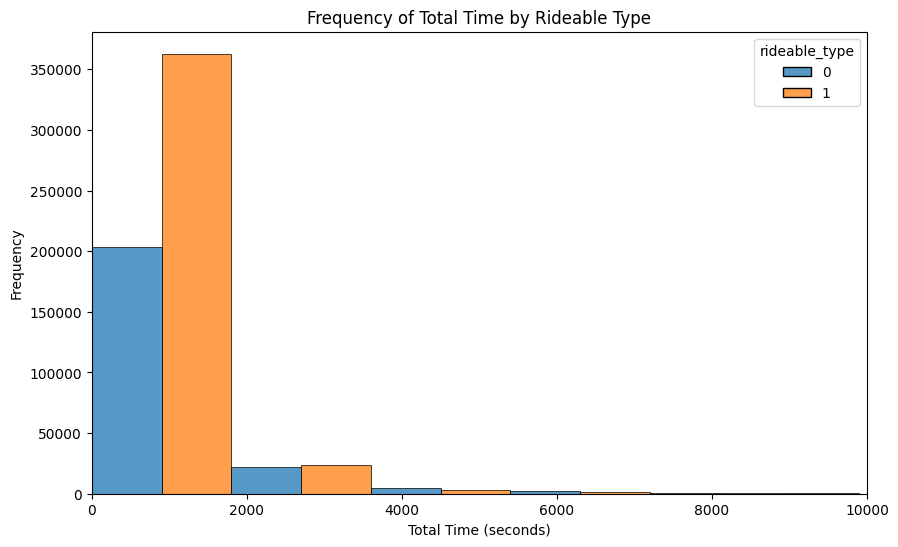

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=new_df, x='total_time', hue='rideable_type', bins=50, multiple="dodge")
plt.title('Frequency of Total Time by Rideable Type')
plt.xlabel('Total Time (seconds)')
plt.ylabel('Frequency')
plt.xlim(0, 10000)  # Limit the x-axis to 10000
plt.show()


In [ ]:
# Create a copy to avoid modifying the original DataFrame
wsdf = new_df[['member_casual', 'total_time', 'started_at', 'rideable_type', 'end_lat', 'end_lng', 'start_lat', 'start_lng', 'distance']].copy()

# Display the first few rows of the new DataFrame
print(wsdf.head())


  member_casual  total_time              started_at rideable_type    end_lat  \
0             1     116.545 2025-03-07 08:45:59.496             0  38.905711   
1             1     470.316 2025-03-24 09:37:36.233             1  38.903741   
2             1    2495.665 2025-03-10 08:37:28.678             0  38.878854   
3             1    2703.997 2025-03-11 08:39:00.732             0  38.878854   
4             1    2717.690 2025-03-25 08:22:12.145             0  38.878854   

     end_lng  start_lat  start_lng  distance  
0 -77.047318  38.908905 -77.044780  0.417571  
1 -77.042452  38.912181 -77.066074  2.249071  
2 -77.005727  38.894941 -77.091690  7.652300  
3 -77.005727  38.894941 -77.091690  7.652300  
4 -77.005727  38.894941 -77.091690  7.652300  


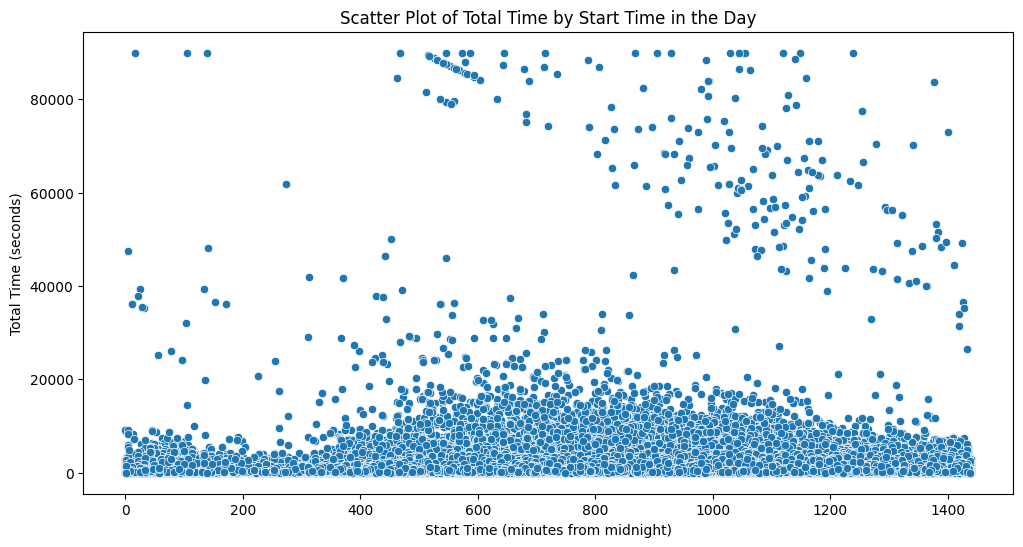

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the minute of the day from the 'started_at' column
wsdf['start_time_minute'] = wsdf['started_at'].dt.hour * 60 + wsdf['started_at'].dt.minute
wsdf['started_at_day'] = pd.to_datetime(wsdf['started_at'], format='%H:%M').dt.time

# Extract the start time in minutes from midnight
wsdf['start_minutes'] = wsdf['started_at_day'].apply(lambda x: x.hour * 60 + x.minute)


plt.figure(figsize=(12, 6))
sns.scatterplot(x='start_minutes', y='total_time', data=wsdf)
plt.title('Scatter Plot of Total Time by Start Time in the Day')
plt.xlabel('Start Time (minutes from midnight)')
plt.ylabel('Total Time (seconds)')
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


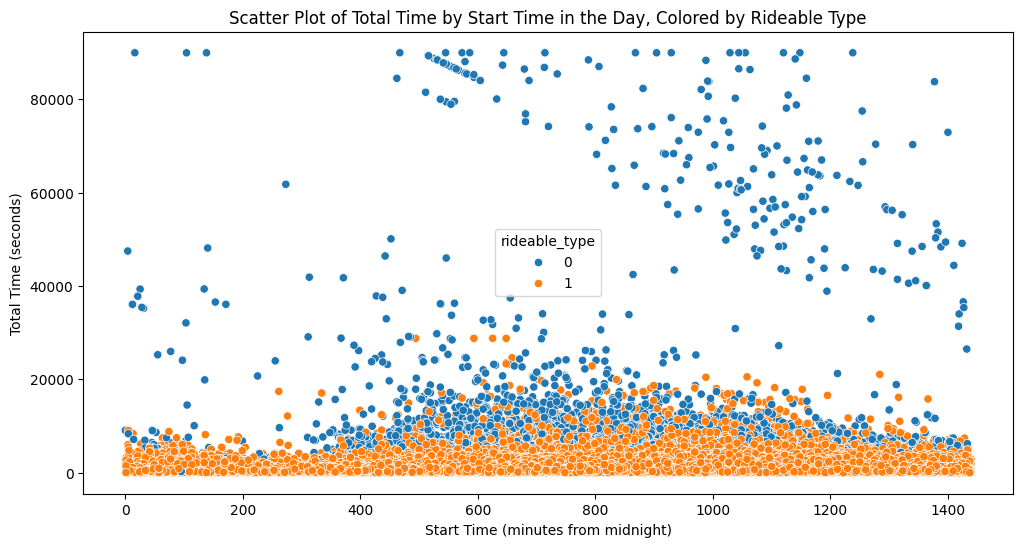

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x='start_minutes', y='total_time', hue='rideable_type', data=wsdf)
plt.title('Scatter Plot of Total Time by Start Time in the Day, Colored by Rideable Type')
plt.xlabel('Start Time (minutes from midnight)')
plt.ylabel('Total Time (seconds)')
plt.show()


# The trees

The project aims to visuallise how decicion tree models would classify member and casual trips.

In [ ]:
# Create a copy to avoid modifying the original DataFrame
final_df = wsdf[['started_at', 'total_time', 'rideable_type', 'member_casual', 'distance',  'end_lat', 'end_lng', 'start_lat', 'start_lng']].copy()

# Extract the weekday (Monday=0, Sunday=6) and add 1 to get 1-7 representation
final_df['Week_day'] = final_df['started_at'].dt.weekday + 1

# Select the desired columns for the final DataFrame
final_df = final_df[['Week_day', 'total_time', 'rideable_type', 'member_casual', 'distance',  'end_lat', 'end_lng', 'start_lat', 'start_lng']]

# Display the first few rows of the final DataFrame
print(final_df.head())


   Week_day  total_time rideable_type member_casual  distance    end_lat  \
0         5     116.545             0             1  0.417571  38.905711   
1         1     470.316             1             1  2.249071  38.903741   
2         1    2495.665             0             1  7.652300  38.878854   
3         2    2703.997             0             1  7.652300  38.878854   
4         2    2717.690             0             1  7.652300  38.878854   

     end_lng  start_lat  start_lng  
0 -77.047318  38.908905 -77.044780  
1 -77.042452  38.912181 -77.066074  
2 -77.005727  38.894941 -77.091690  
3 -77.005727  38.894941 -77.091690  
4 -77.005727  38.894941 -77.091690  


In [ ]:
final_df.head()

,Week_day,total_time,rideable_type,member_casual,distance,end_lat,end_lng,start_lat,start_lng
0,5,116.545,0,1,0.417571,38.905711,-77.047318,38.908905,-77.044780
1,1,470.316,1,1,2.249071,38.903741,-77.042452,38.912181,-77.066074
2,1,2495.665,0,1,7.652300,38.878854,-77.005727,38.894941,-77.091690
3,2,2703.997,0,1,7.652300,38.878854,-77.005727,38.894941,-77.091690
4,2,2717.690,0,1,7.652300,38.878854,-77.005727,38.894941,-77.091690


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error as MSE


In [ ]:
X = final_df.drop(['member_casual'], axis=1)
y = final_df['member_casual']

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y,test_size=0.2,random_state=99)

clf = DecisionTreeClassifier(criterion='entropy', random_state=99)

In [ ]:
clf.fit(X_train,y_train)
y_pred= clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.6974626258111376

In [ ]:
accuracy = float(np.sum(y_pred==y_test))/y_test.shape[0]
accuracy

0.6974626258111376

The test's accuracy (its rate of correctly identifying true positives) is 62.29%; this isn't fully ideal.

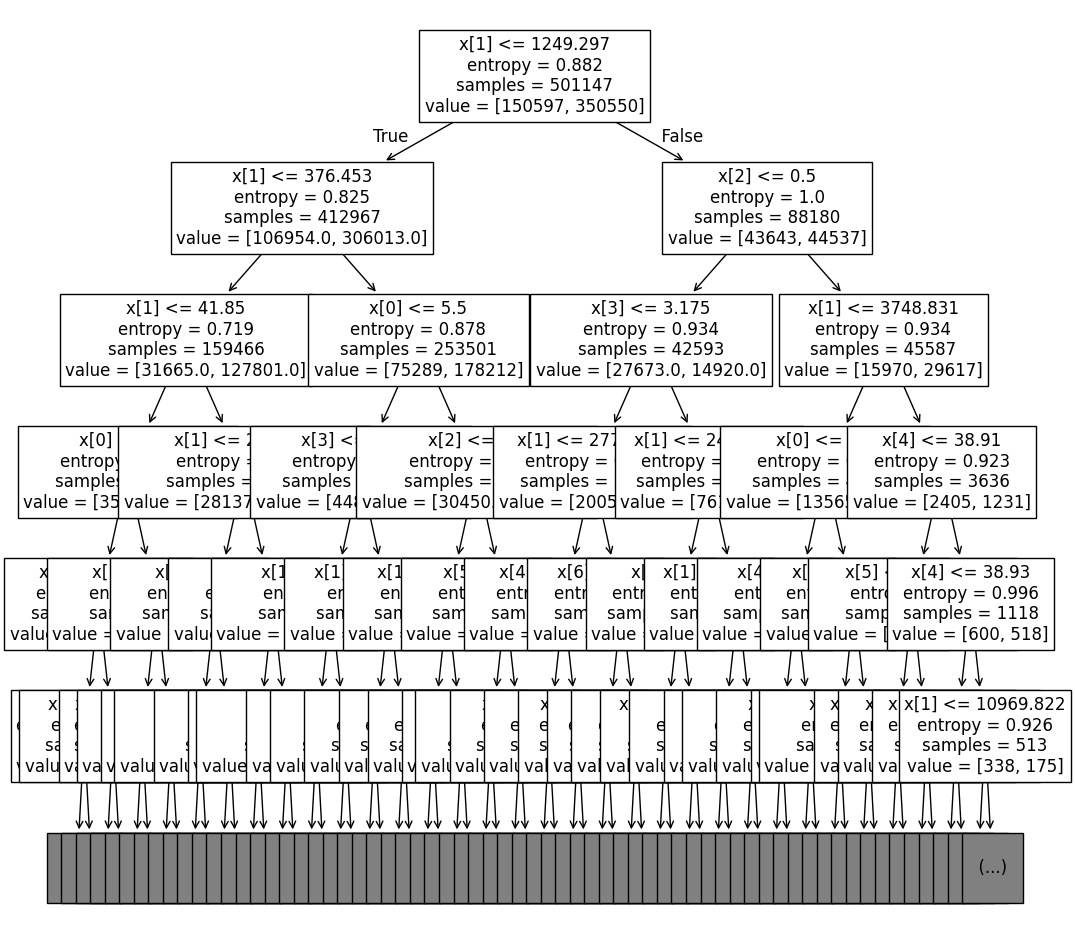

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))
tree.plot_tree(decision_tree=clf, max_depth= 5,fontsize=12);

In [ ]:
# Comparing decision tree output to randomforest output

from sklearn.ensemble import RandomForestClassifier
rfcl = RandomForestClassifier(n_estimators=100, random_state=1)
rfcl.fit(X_train, y_train)
rf_pred= rfcl.predict(X_test)
accuracy = float(np.sum(rf_pred==y_test))/y_test.shape[0]
print('Accuracy : ', accuracy*100, '%')

Accuracy :  76.89784255349717 %


Text(0.5, 427.9555555555555, 'Predicted label')

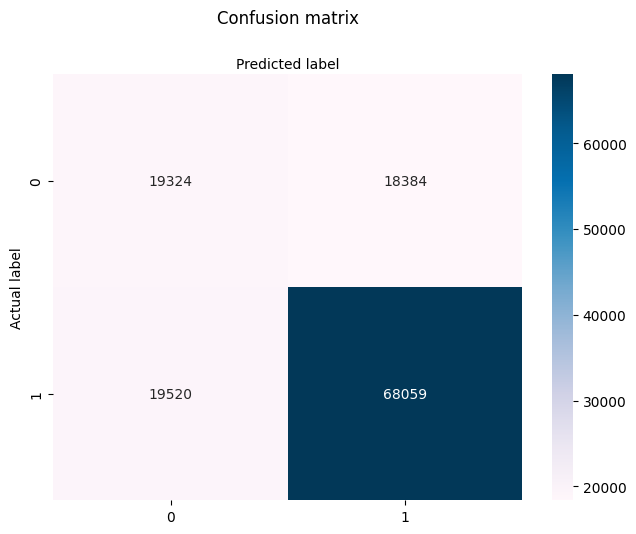

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots()

sns.heatmap(pd.DataFrame(conf), annot=True, cmap="PuBu" ,fmt='g')

ax.xaxis.set_label_position("top")

plt.tight_layout()

plt.title('Confusion matrix', y=1.1)

plt.ylabel('Actual label')

plt.xlabel('Predicted label')

## Some smaller trees

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y,test_size=0.2,random_state=99)

clf = DecisionTreeClassifier(criterion='entropy', max_depth=3 , random_state=99)

In [ ]:
clf.fit(X_train,y_train)
y_pred= clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.7283277594642701

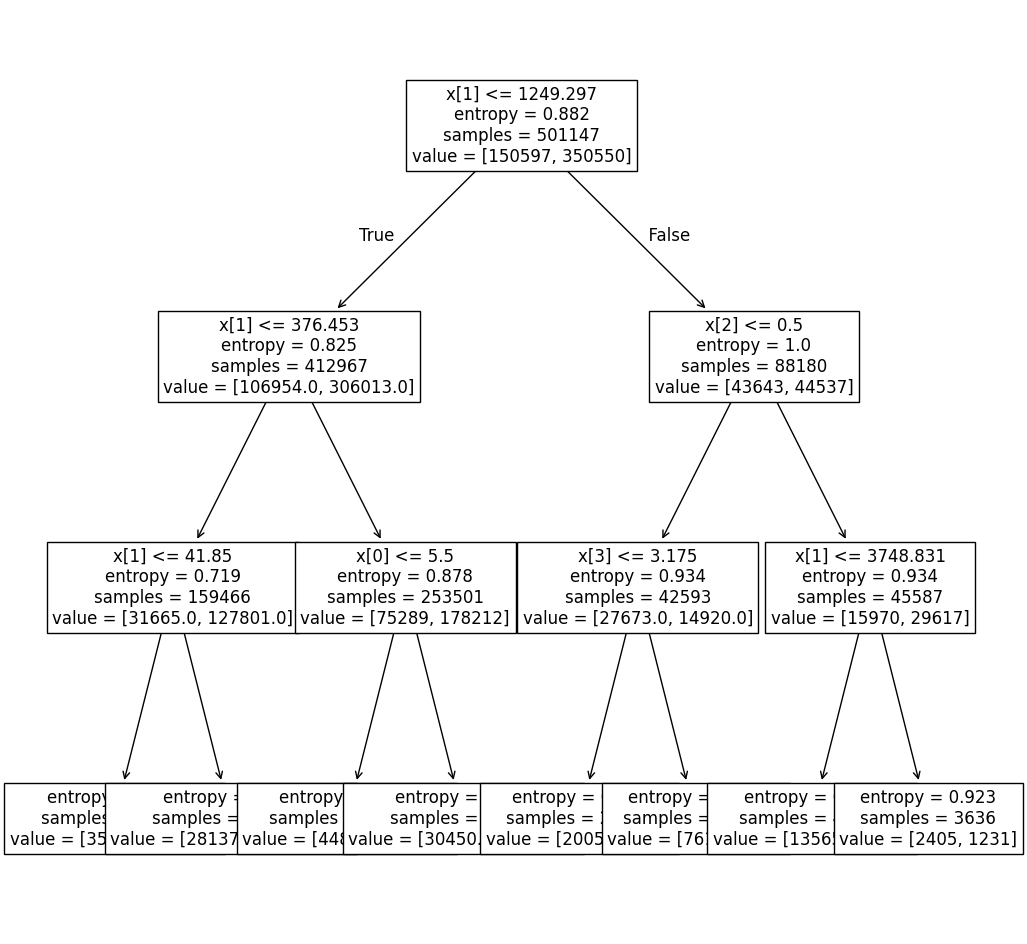

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
tree.plot_tree(decision_tree=clf, max_depth= 5,fontsize=12);